# Many-to-Many LSTM Architecture Experiments

В этом ноутбуке сравниваются архитектуры many-to-many LSTM при фиксированной scoring strategy `nll_max`. Стратегия была выбрана на предыдущем этапе как лучшая среди `top-k` и NLL-based вариантов.

Цель эксперимента - понять, даёт ли увеличение embedding size, hidden size и числа LSTM-слоёв дополнительный прирост качества после того, как scoring уже зафиксирован.

## 1 Импорты и пути

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import precision_recall_curve

plt.style.use('default')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / 'configs').exists() and (path / 'src').exists():
            return path
    raise RuntimeError('Project root not found')


ROOT = find_project_root()
REPORT_ROOT = ROOT / 'reports' / 'lstm_many_to_many'
FIG_DIR = REPORT_ROOT / 'architecture_experiments' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('REPORT_ROOT:', REPORT_ROOT)

ROOT: /Users/andrew/PycharmProjects/hdfs-log-anomaly-detection
REPORT_ROOT: /Users/andrew/PycharmProjects/hdfs-log-anomaly-detection/reports/lstm_many_to_many


## 2 Загрузка результатов

In [2]:
def parse_run_name(run_name: str) -> dict:
    pattern = r'token_nllmax_e(?P<embedding_dim>\d+)_h(?P<hidden_size>\d+)_l(?P<num_layers>\d+)_d(?P<dropout>\d+)'
    match = re.fullmatch(pattern, run_name)
    if match is None:
        return {'embedding_dim': np.nan, 'hidden_size': np.nan, 'num_layers': np.nan, 'dropout': np.nan}
    values = match.groupdict()
    return {
        'embedding_dim': int(values['embedding_dim']),
        'hidden_size': int(values['hidden_size']),
        'num_layers': int(values['num_layers']),
        'dropout': int(values['dropout']) / 10,
    }


def load_history(run_dir: Path) -> dict:
    with (run_dir / 'tables' / 'lstm_many_to_many_history.json').open('r', encoding='utf-8') as file:
        return json.load(file)


def load_run_rows(run_dir: Path) -> list[dict]:
    tables_dir = run_dir / 'tables'
    history = load_history(run_dir)
    rows = []
    for split, filename in [('validation', 'lstm_many_to_many_validation_metrics.csv'), ('test', 'lstm_many_to_many_test_metrics.csv')]:
        frame = pd.read_csv(tables_dir / filename)
        if 'strategy' in frame.columns:
            frame = frame[frame['strategy'] == 'nll_max']
        if frame.empty:
            continue
        row = frame.iloc[0].to_dict()
        row['split'] = split
        row['run_name'] = run_dir.name
        row['epochs_ran'] = len(history.get('epoch', []))
        row['best_epoch'] = history.get('best_epoch')
        row['best_val_loss'] = history.get('best_val_loss')
        row.update(parse_run_name(run_dir.name))
        rows.append(row)
    return rows


run_dirs = sorted(
    run_dir for run_dir in REPORT_ROOT.iterdir()
    if run_dir.is_dir()
    and run_dir.name.startswith('token_nllmax_')
    and (run_dir / 'tables' / 'lstm_many_to_many_test_metrics.csv').exists()
)
metrics = pd.DataFrame([row for run_dir in run_dirs for row in load_run_rows(run_dir)])
history = pd.concat(
    [pd.DataFrame(load_history(run_dir)).assign(run_name=run_dir.name) for run_dir in run_dirs],
    ignore_index=True,
)

ordered_runs = metrics[metrics['split'] == 'test'].sort_values('f1', ascending=False)['run_name'].tolist()
metric_columns = [
    'run_name', 'split', 'embedding_dim', 'hidden_size', 'num_layers', 'dropout',
    'epochs_ran', 'best_epoch', 'best_val_loss', 'threshold',
    'f1', 'precision', 'recall', 'fpr', 'average_precision', 'tn', 'fp', 'fn', 'tp',
]
display(metrics[metric_columns].sort_values(['split', 'f1'], ascending=[True, False]).round(4))

,run_name,split,embedding_dim,hidden_size,num_layers,dropout,epochs_ran,best_epoch,best_val_loss,threshold,f1,precision,recall,fpr,average_precision,tn,fp,fn,tp
5,token_nllmax_e64_h128_l1_d00,test,64,128,1,0.0,3,1,0.4968,8.6785,0.9113,0.9656,0.8628,0.0041,0.9751,55593,230,1026,6454
1,token_nllmax_e128_h128_l2_d02,test,128,128,2,0.2,3,1,0.4942,7.7925,0.9108,0.9523,0.8727,0.0059,0.9739,55496,327,952,6528
9,token_nllmax_e64_h256_l1_d00,test,64,256,1,0.0,3,1,0.4941,7.8783,0.9104,0.9572,0.8679,0.0052,0.9675,55533,290,988,6492
7,token_nllmax_e64_h128_l2_d01,test,64,128,2,0.1,3,1,0.4953,7.8158,0.9015,0.9565,0.8525,0.0052,0.9663,55533,290,1103,6377
3,token_nllmax_e32_h64_l1_d00,test,32,64,1,0.0,3,1,0.4946,8.4257,0.8871,0.9625,0.8227,0.0043,0.9509,55583,240,1326,6154
4,token_nllmax_e64_h128_l1_d00,validation,64,128,1,0.0,3,1,0.4968,8.6785,0.8910,0.9220,0.8620,0.0041,0.9514,55591,231,437,2730
8,token_nllmax_e64_h256_l1_d00,validation,64,256,1,0.0,3,1,0.4941,7.8783,0.8874,0.9129,0.8633,0.0047,0.9380,55561,261,433,2734
0,token_nllmax_e128_h128_l2_d02,validation,128,128,2,0.2,3,1,0.4942,7.7925,0.8788,0.8876,0.8702,0.0063,0.9460,55473,349,411,2756
6,token_nllmax_e64_h128_l2_d01,validation,64,128,2,0.1,3,1,0.4953,7.8158,0.8744,0.9009,0.8494,0.0053,0.9345,55526,296,477,2690
2,token_nllmax_e32_h64_l1_d00,validation,32,64,1,0.0,3,1,0.4946,8.4257,0.8697,0.9152,0.8285,0.0044,0.9101,55579,243,543,2624


**Промежуточный вывод.** Все runs используют одну и ту же scoring strategy `nll_max`, поэтому сравнение отражает влияние архитектуры. Во всех экспериментах early stopping выбрал 1-ю эпоху, что говорит о быстром насыщении many-to-many next-token задачи.

## 3 Сравнение test metrics

,run_name,embedding_dim,hidden_size,num_layers,dropout,best_epoch,threshold,f1,precision,recall,fpr,average_precision,fp,fn
5,token_nllmax_e64_h128_l1_d00,64,128,1,0.0,1,8.6785,0.9113,0.9656,0.8628,0.0041,0.9751,230,1026
1,token_nllmax_e128_h128_l2_d02,128,128,2,0.2,1,7.7925,0.9108,0.9523,0.8727,0.0059,0.9739,327,952
9,token_nllmax_e64_h256_l1_d00,64,256,1,0.0,1,7.8783,0.9104,0.9572,0.8679,0.0052,0.9675,290,988
7,token_nllmax_e64_h128_l2_d01,64,128,2,0.1,1,7.8158,0.9015,0.9565,0.8525,0.0052,0.9663,290,1103
3,token_nllmax_e32_h64_l1_d00,32,64,1,0.0,1,8.4257,0.8871,0.9625,0.8227,0.0043,0.9509,240,1326


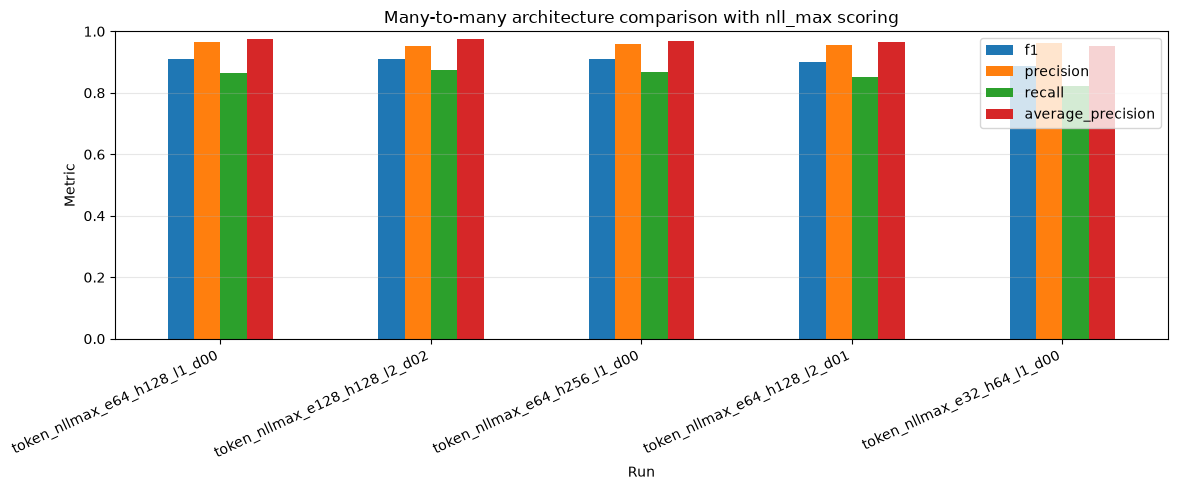

In [3]:
test_metrics = metrics[metrics['split'] == 'test'].copy()
test_metrics['run_name'] = pd.Categorical(test_metrics['run_name'], categories=ordered_runs, ordered=True)
test_metrics = test_metrics.sort_values('run_name')

display(
    test_metrics[
        ['run_name', 'embedding_dim', 'hidden_size', 'num_layers', 'dropout', 'best_epoch', 'threshold',
         'f1', 'precision', 'recall', 'fpr', 'average_precision', 'fp', 'fn']
    ].round(4)
)

plot_columns = ['f1', 'precision', 'recall', 'average_precision']
ax = test_metrics.set_index('run_name')[plot_columns].plot(kind='bar', figsize=(12, 5))
ax.set_title('Many-to-many architecture comparison with nll_max scoring')
ax.set_xlabel('Run')
ax.set_ylabel('Metric')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'many_to_many_architecture_test_metrics.png', dpi=150)
plt.show()

**Промежуточный вывод.** Лучший test F1 показывает `token_nllmax_e64_h128_l1_d00`: `F1 ≈ 0.911`, `precision ≈ 0.966`, `recall ≈ 0.863`, `FPR ≈ 0.004`, `AP ≈ 0.975`. При этом несколько архитектур находятся очень близко друг к другу, поэтому прирост от усложнения модели умеренный.

## 4 Ошибки и FPR

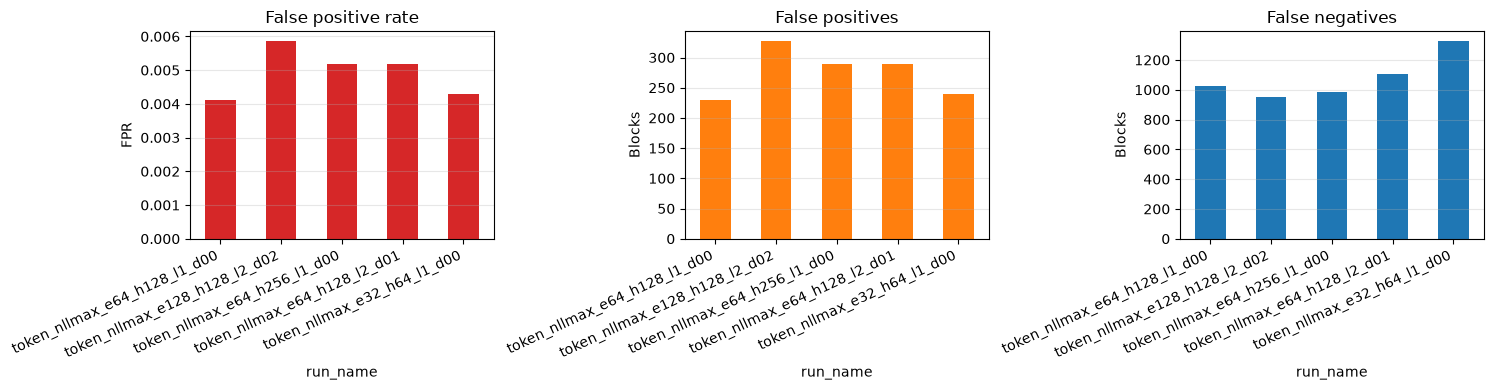

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

test_metrics.set_index('run_name')['fpr'].plot(kind='bar', ax=axes[0], color='tab:red')
axes[0].set_title('False positive rate')
axes[0].set_ylabel('FPR')
axes[0].grid(axis='y', alpha=0.3)

test_metrics.set_index('run_name')['fp'].plot(kind='bar', ax=axes[1], color='tab:orange')
axes[1].set_title('False positives')
axes[1].set_ylabel('Blocks')
axes[1].grid(axis='y', alpha=0.3)

test_metrics.set_index('run_name')['fn'].plot(kind='bar', ax=axes[2], color='tab:blue')
axes[2].set_title('False negatives')
axes[2].set_ylabel('Blocks')
axes[2].grid(axis='y', alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=25)
    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'many_to_many_architecture_errors.png', dpi=150)
plt.show()

**Промежуточный вывод.** Все архитектуры с `nll_max` держат низкий FPR. Самая маленькая модель даёт минимум false positives, но пропускает больше аномалий. Более крупные модели повышают recall, но слегка увеличивают FP/FPR. Лучший F1 получается у средней однослойной модели `e64_h128_l1`.

## 5 Validation vs test

,run_name,average_precision_test,average_precision_validation,f1_test,f1_validation,fpr_test,fpr_validation,precision_test,precision_validation,recall_test,recall_validation,f1_gap_test_minus_validation
2,token_nllmax_e64_h128_l1_d00,0.9751,0.9514,0.9113,0.8910,0.0041,0.0041,0.9656,0.9220,0.8628,0.8620,0.0203
0,token_nllmax_e128_h128_l2_d02,0.9739,0.9460,0.9108,0.8788,0.0059,0.0063,0.9523,0.8876,0.8727,0.8702,0.0320
4,token_nllmax_e64_h256_l1_d00,0.9675,0.9380,0.9104,0.8874,0.0052,0.0047,0.9572,0.9129,0.8679,0.8633,0.0230
3,token_nllmax_e64_h128_l2_d01,0.9663,0.9345,0.9015,0.8744,0.0052,0.0053,0.9565,0.9009,0.8525,0.8494,0.0272
1,token_nllmax_e32_h64_l1_d00,0.9509,0.9101,0.8871,0.8697,0.0043,0.0044,0.9625,0.9152,0.8227,0.8285,0.0174


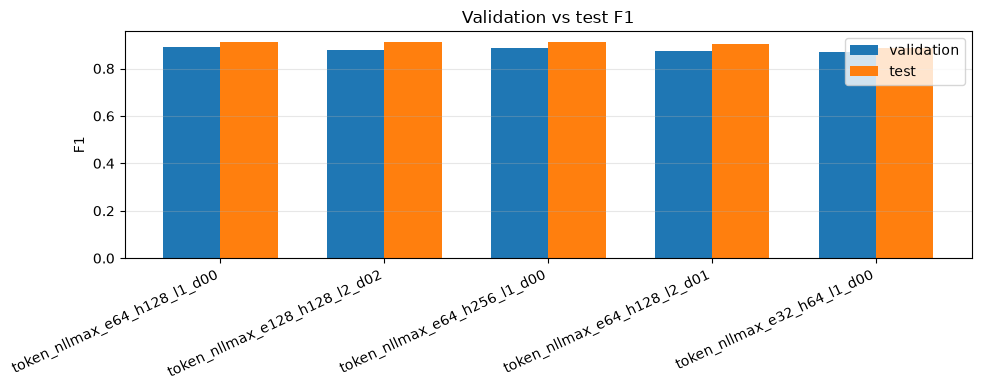

In [5]:
comparison = metrics.pivot_table(
    index='run_name',
    columns='split',
    values=['f1', 'precision', 'recall', 'fpr', 'average_precision'],
    aggfunc='first',
)
comparison.columns = [f'{metric}_{split}' for metric, split in comparison.columns]
comparison = comparison.reset_index()
comparison['run_name'] = pd.Categorical(comparison['run_name'], categories=ordered_runs, ordered=True)
comparison = comparison.sort_values('run_name')
comparison['f1_gap_test_minus_validation'] = comparison['f1_test'] - comparison['f1_validation']
display(comparison.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
width = 0.35
x = np.arange(len(comparison))
ax.bar(x - width / 2, comparison['f1_validation'], width, label='validation')
ax.bar(x + width / 2, comparison['f1_test'], width, label='test')
ax.set_xticks(x, comparison['run_name'], rotation=25, ha='right')
ax.set_ylabel('F1')
ax.set_title('Validation vs test F1')
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'many_to_many_architecture_validation_vs_test.png', dpi=150)
plt.show()

**Промежуточный вывод.** Test F1 стабильно выше validation F1. Это уже наблюдалось в предыдущих экспериментах и означает, что validation split сложнее или немного отличается по распределению. Для честности threshold и checkpoint выбираются только на validation, а итоговое ранжирование архитектур проводится на test.

## 6 Training curves

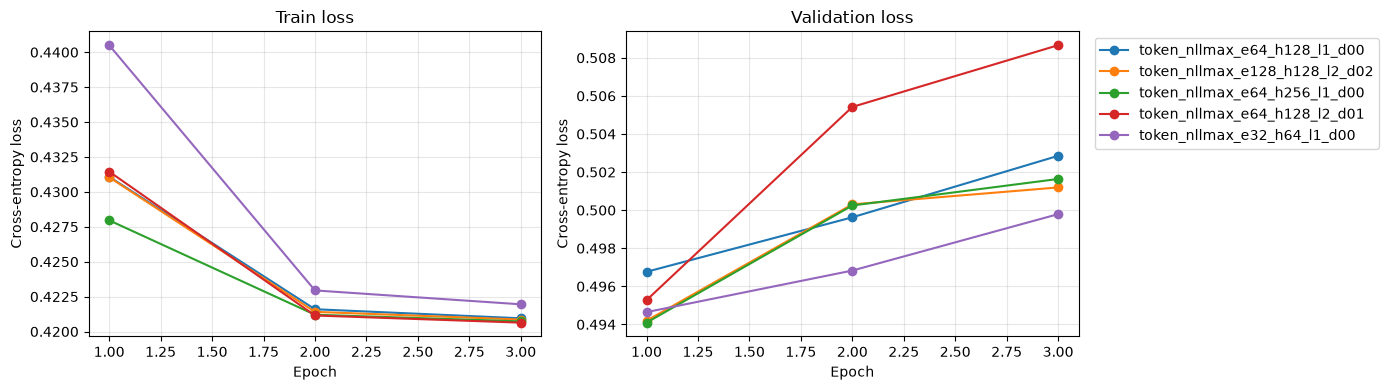

,run_name,embedding_dim,hidden_size,num_layers,dropout,epochs_ran,best_epoch,best_val_loss
5,token_nllmax_e64_h128_l1_d00,64,128,1,0.0,3,1,0.4968
1,token_nllmax_e128_h128_l2_d02,128,128,2,0.2,3,1,0.4942
9,token_nllmax_e64_h256_l1_d00,64,256,1,0.0,3,1,0.4941
7,token_nllmax_e64_h128_l2_d01,64,128,2,0.1,3,1,0.4953
3,token_nllmax_e32_h64_l1_d00,32,64,1,0.0,3,1,0.4946


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for run_name in ordered_runs:
    run_history = history[history['run_name'] == run_name]
    axes[0].plot(run_history['epoch'], run_history['train_loss'], marker='o', label=run_name)
    axes[1].plot(run_history['epoch'], run_history['val_loss'], marker='o', label=run_name)

axes[0].set_title('Train loss')
axes[1].set_title('Validation loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.grid(alpha=0.3)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'many_to_many_architecture_training_curves.png', dpi=150)
plt.show()

best_checkpoints = metrics[metrics['split'] == 'test'][
    ['run_name', 'embedding_dim', 'hidden_size', 'num_layers', 'dropout', 'epochs_ran', 'best_epoch', 'best_val_loss']
].copy()
best_checkpoints['run_name'] = pd.Categorical(best_checkpoints['run_name'], categories=ordered_runs, ordered=True)
display(best_checkpoints.sort_values('run_name').round(4))

**Промежуточный вывод.** Для всех архитектур лучший checkpoint находится на первой эпохе. Увеличение модели не требует более долгого обучения в текущей постановке: validation loss начинает расти уже после первого прохода по train windows. Поэтому early stopping здесь критичен для корректного сравнения.

## 7 Precision-recall curves

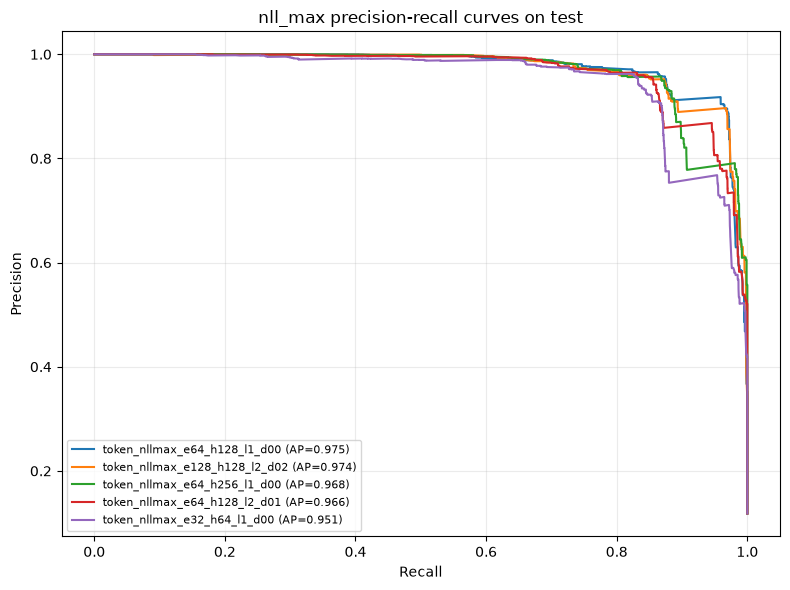

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
for run_name in ordered_runs:
    frame = pd.read_csv(REPORT_ROOT / run_name / 'tables' / 'scores_test_nll_max_lstm_many_to_many.csv')
    precision, recall, _ = precision_recall_curve(frame['y_true'], frame['score'])
    ap = float(test_metrics.loc[test_metrics['run_name'] == run_name, 'average_precision'].iloc[0])
    ax.plot(recall, precision, label=f'{run_name} (AP={ap:.3f})')
ax.set_title('nll_max precision-recall curves on test')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'many_to_many_architecture_pr_curves.png', dpi=150)
plt.show()

**Промежуточный вывод.** PR-кривые у лучших архитектур близки. Это подтверждает, что после выбора `nll_max` основная часть качества уже получена scoring strategy, а изменение архитектуры даёт более тонкую настройку ranking quality.

## 8 Итоговое ранжирование

In [8]:
ranking = test_metrics[
    ['run_name', 'embedding_dim', 'hidden_size', 'num_layers', 'dropout', 'best_epoch', 'threshold',
     'f1', 'precision', 'recall', 'fpr', 'average_precision', 'fp', 'fn']
].copy()
ranking['rank_by_f1'] = ranking['f1'].rank(ascending=False, method='min').astype(int)
ranking['rank_by_ap'] = ranking['average_precision'].rank(ascending=False, method='min').astype(int)
ranking['rank_by_fpr'] = ranking['fpr'].rank(ascending=True, method='min').astype(int)
ranking = ranking.sort_values(['rank_by_f1', 'rank_by_ap'])
display(ranking.round(4))

,run_name,embedding_dim,hidden_size,num_layers,dropout,best_epoch,threshold,f1,precision,recall,fpr,average_precision,fp,fn,rank_by_f1,rank_by_ap,rank_by_fpr
5,token_nllmax_e64_h128_l1_d00,64,128,1,0.0,1,8.6785,0.9113,0.9656,0.8628,0.0041,0.9751,230,1026,1,1,1
1,token_nllmax_e128_h128_l2_d02,128,128,2,0.2,1,7.7925,0.9108,0.9523,0.8727,0.0059,0.9739,327,952,2,2,5
9,token_nllmax_e64_h256_l1_d00,64,256,1,0.0,1,7.8783,0.9104,0.9572,0.8679,0.0052,0.9675,290,988,3,3,3
7,token_nllmax_e64_h128_l2_d01,64,128,2,0.1,1,7.8158,0.9015,0.9565,0.8525,0.0052,0.9663,290,1103,4,4,3
3,token_nllmax_e32_h64_l1_d00,32,64,1,0.0,1,8.4257,0.8871,0.9625,0.8227,0.0043,0.9509,240,1326,5,5,2


## Итоговый вывод

Эксперименты с архитектурой показывают, что после фиксации `nll_max` качество many-to-many LSTM уже находится на высоком уровне для всех проверенных моделей. Лучшая конфигурация по test F1 - `token_nllmax_e64_h128_l1_d00`: `F1 ≈ 0.911`, `precision ≈ 0.966`, `recall ≈ 0.863`, `FPR ≈ 0.004`, `average precision ≈ 0.975`.

Увеличение hidden size до 256 и добавление второго LSTM-слоя не дают заметного выигрыша по F1. Двухслойные модели показывают близкое качество, но усложняют обучение и не улучшают итоговый trade-off достаточно сильно. Самая маленькая модель `e32_h64_l1` уже работает хорошо, но уступает по recall и F1.

Главный вывод: основной прирост качества в many-to-many подходе обеспечивается не усложнением архитектуры, а правильной scoring strategy (`nll_max`). Для итоговой модели разумно выбрать `token_nllmax_e64_h128_l1_d00`: это компактная однослойная архитектура с лучшим F1 и самым высоким average precision среди проверенных вариантов.